# CFPB Complaints — Logistic Regression on TF-IDF

Interpretable baseline for 10-class product classification, benchmarked against a
fine-tuned DistilBERT on identical data.

This notebook owns the **split**, and the split is where this project's real work is.
It writes `train/val/test.parquet` (random) and `*_temporal.parquet` (time-ordered)
so DistilBERT is scored on the exact same rows.

Three properties the split must have, none of which the first version had:

1. **No text can straddle two splits** — not even after cleaning. Roughly 15% of the CFPB
   pool is template letters filed hundreds or thousands of times.
2. **Evaluation is never rebalanced.** Training may be; test must look like reality.
3. **A held-out validation set** does model selection, so the test set is read once.

In [1]:
import hashlib
import os
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import softmax
from scipy.stats import chi2
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
PARQUET = "cfpb_filtered.parquet"

pd.set_option("display.max_colwidth", 60)
print("pandas", pd.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

pandas 3.0.0
scikit-learn 1.9.0


## Step 1 — Load the filtered data

Reads the parquet and keeps `narrative` (text), `product` (label) and `date_received`
(needed for the temporal split in Step 3).

In [2]:
df = pd.read_parquet(PARQUET, columns=["narrative", "product", "date_received"])

print("shape:", df.shape)
print()
class_counts = df["product"].value_counts()
print(class_counts.to_string())

EXPECTED_ROWS, EXPECTED_CLASSES = 407_321, 10
assert len(df) == EXPECTED_ROWS, f"expected {EXPECTED_ROWS:,} rows, got {len(df):,}"
assert df["product"].nunique() == EXPECTED_CLASSES, (
    f"expected {EXPECTED_CLASSES} classes, got {df['product'].nunique()}"
)
print(f"\nCheckpoint OK: {len(df):,} rows, {df['product'].nunique()} classes")
print(f"raw imbalance ratio (max/min): {class_counts.max() / class_counts.min():.1f}x")

shape: (407321, 3)

product
Debt collection                                            134953
Money transfer, virtual currency, or money service          72921
Checking or savings account                                 69343
Credit card                                                 58916
Mortgage                                                    20497
Vehicle loan or lease                                       16712
Student loan                                                14163
Payday loan, title loan, personal loan, or advance loan     11271
Prepaid card                                                 5014
Debt or credit management                                    3531

Checkpoint OK: 407,321 rows, 10 classes
raw imbalance ratio (max/min): 38.2x


## Step 2 — Deduplicate on a canonical key

The CFPB pool is template-driven: one Cash App narrative appears 7,758 times, and 104
distinct texts are filed 50+ times each. Splitting rows at random puts copies of the same
letter on both sides of the split, so the model is scored on text it memorised.

Deduplicating on the raw `narrative` is **not enough**. The model never sees the raw string
— it sees `clean_text(narrative)`, which strips digits, punctuation and case. Two narratives
that differ only in a redacted amount collapse to the same input after cleaning. On this
pool that collapse creates thousands of extra collisions, and it hits Logistic Regression
harder than DistilBERT because LR's cleaning is the more aggressive of the two — so leaving
it unhandled hands LR a memorisation advantage in the very comparison this project exists
to make.

So the key used for deduplication, conflict detection and splitting is `canon()` — the same
normalisation the model input goes through. Two documents the model cannot tell apart are
treated as one document here.

Two by-products, both used later:

- **Conflicting labels.** Where one key carries more than one `product`, the label is not
  recoverable and the rows are dropped. (Mostly a handful of filers picking a different
  drop-down on a mass-filed template — not annotator disagreement, see the README.)
- **`n_copies`.** How many times each key was filed, recorded *before* deduplication, so
  Step 6 can report both a text-diversity view and an intake-volume view of the same test
  set without ever putting a duplicate into training.

In [3]:
# Split key: the same normalisation clean_text applies, run BEFORE the split so that two
# narratives the model cannot tell apart can never land on opposite sides of it.
DATE_MASK = re.compile(r"X{2}/X{2}/(?:X+|\d{2,4}|year>|scrub>)?")
X_RUN = re.compile(r"X{2,}")
NON_ALPHA = re.compile(r"[^a-z\s]")
WS = re.compile(r"\s+")


def canon(text: str) -> str:
    text = DATE_MASK.sub(" ", text)
    text = X_RUN.sub(" ", text)
    text = text.lower()
    text = NON_ALPHA.sub(" ", text)
    return WS.sub(" ", text).strip()


df["canon_key"] = df["narrative"].map(canon)
# Stored on disk in place of the full normalised text -- it is only ever used for
# set-membership and joins, and keeping the text doubled every parquet file.
def key_hash(k):
    return hashlib.sha1(k.encode()).hexdigest()[:16]

n_before = len(df)
df = df[df["canon_key"].str.len() > 0]
print(f"dropped {n_before - len(df)} rows that normalise to an empty string")

# Same wording, different product -> the label is not recoverable. Drop the key entirely.
n_labels = df.groupby("canon_key")["product"].nunique()
conflicting = set(n_labels[n_labels > 1].index)
conflict_rows = int(df["canon_key"].isin(conflicting).sum())
print(f"conflicting keys : {len(conflicting):,}  ({conflict_rows:,} rows, "
      f"{100 * conflict_rows / len(df):.1f}% of the pool)")
df = df[~df["canon_key"].isin(conflicting)]

# Multiplicity recorded BEFORE dedup, so the intake-volume view stays available.
df["n_copies"] = df["canon_key"].map(df["canon_key"].value_counts())

df["key"] = df["canon_key"].map(key_hash)
pool = df.drop_duplicates(subset="canon_key").reset_index(drop=True)
assert pool["key"].nunique() == len(pool), "hash collision in the split key"

pool_counts = pool["product"].value_counts()
print(f"\nPOOL after canonical dedup: {len(pool):,} distinct complaints "
      f"(from {n_before:,} rows)")
print(f"imbalance ratio           : {pool_counts.max() / pool_counts.min():.1f}x")
print(f"most-filed single text    : {pool['n_copies'].max():,} copies")
print()
print((pool_counts / len(pool) * 100).round(2).to_string())

dropped 22 rows that normalise to an empty string


conflicting keys : 210  (24,007 rows, 5.9% of the pool)



POOL after canonical dedup: 334,658 distinct complaints (from 407,321 rows)
imbalance ratio           : 28.9x
most-filed single text    : 7,111 copies

product
Debt collection                                            29.44
Checking or savings account                                19.31
Credit card                                                16.78
Money transfer, virtual currency, or money service         13.37
Mortgage                                                    6.12
Vehicle loan or lease                                       4.95
Student loan                                                4.16
Payday loan, title loan, personal loan, or advance loan     3.35
Prepaid card                                                1.50
Debt or credit management                                   1.02


## Step 3 — Two splits, and the training set is the only one that gets rebalanced

**Training data may be rebalanced. Evaluation data may not.** The first version of this
notebook capped every class at 8,000 rows *before* splitting, which left the test set close
to uniform while the real pool runs about 29:1. Every per-class number it produced was
measured against a world that does not exist.

Here the cap is applied to the training pool **only**, after the evaluation sets are already
held out at the pool's own distribution. The cap is a **GPU budget** — `class_weight='balanced'`
in Step 5 is what handles imbalance, and it does so regardless of the cap.

Two splits are written, and the README reports both:

- **Random (primary)** — 70/15/15 stratified. Answers: how well does the model do on the
  average of the last 19 months?
- **Temporal (secondary)** — train through 2026-02, validate on 2026-03/04, test on
  2026-05/07. Answers: how well does it do on months it has never seen?

The second split exists because the class mix is not stationary. Money transfer is 42% of
2025Q1 and 4.5% of 2026Q3, largely because of one filing surge over 2025-01-15/20. A random
split spreads that surge across train and test and quietly grades the model on it.

In [4]:
CAP = 8_000

def stratified_3way(frame, seed=RANDOM_STATE):
    """70/15/15, stratified on the label."""
    tr, tmp = train_test_split(frame, test_size=0.30,
                               stratify=frame["product"], random_state=seed)
    va, te = train_test_split(tmp, test_size=0.50,
                              stratify=tmp["product"], random_state=seed)
    return tr.reset_index(drop=True), va.reset_index(drop=True), te.reset_index(drop=True)


def cap_training_pool(frame, cap=CAP, seed=RANDOM_STATE):
    """Compute budget only -- never applied to val or test."""
    parts = [g.sample(n=min(len(g), cap), random_state=seed)
             for _, g in frame.groupby("product", sort=False)]
    return pd.concat(parts, ignore_index=True)


def no_leakage(*frames):
    keys = [set(f["canon_key"]) for f in frames]
    for a in range(len(keys)):
        for b in range(a + 1, len(keys)):
            assert not (keys[a] & keys[b]), f"canonical-key leak between split {a} and {b}"
    return True


COLS = ["narrative", "product", "key", "n_copies"]

# --- primary: random stratified ------------------------------------------------
train_pool, val_df, test_df = stratified_3way(pool)
train_df = cap_training_pool(train_pool)
no_leakage(train_df, val_df, test_df)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    d[COLS].to_parquet(f"{name}.parquet", index=False)

tc = train_df["product"].value_counts()
print(f"[random]  train pool {len(train_pool):,} -> capped {len(train_df):,}"
      f"  ({(tc == CAP).sum()} classes at the cap, {(tc < CAP).sum()} taken in full)")
print(f"[random]  val {len(val_df):,} | test {len(test_df):,}   (neither is capped)")
print(f"[random]  train imbalance {tc.max() / tc.min():.2f}x  vs  "
      f"test imbalance {test_df['product'].value_counts().max() / test_df['product'].value_counts().min():.1f}x")
print("[random]  canonical-key leakage: none")

# --- secondary: temporal -------------------------------------------------------
d = pd.to_datetime(pool["date_received"])
t_train_pool = pool[d < "2026-03-01"]
t_val_df = pool[(d >= "2026-03-01") & (d < "2026-05-01")]
t_test_df = pool[d >= "2026-05-01"]
t_train_df = cap_training_pool(t_train_pool)
no_leakage(t_train_df, t_val_df, t_test_df)

for name, dd in [("train", t_train_df), ("val", t_val_df), ("test", t_test_df)]:
    dd[COLS].to_parquet(f"{name}_temporal.parquet", index=False)

print(f"\n[temporal] train pool {len(t_train_pool):,} (<= 2026-02) -> capped {len(t_train_df):,}")
print(f"[temporal] val {len(t_val_df):,} (2026-03/04) | test {len(t_test_df):,} (2026-05/07)")
print(f"[temporal] rarest class in test: "
      f"{(t_test_df['product'] == 'Debt or credit management').sum()} rows  <- per-class F1 is noisy here")
print("[temporal] canonical-key leakage: none")

print("\nclass share of each evaluation set (%) -- the two tests differ, and that is the point")
print(pd.DataFrame({
    "pool": pool["product"].value_counts(normalize=True) * 100,
    "random_test": test_df["product"].value_counts(normalize=True) * 100,
    "temporal_test": t_test_df["product"].value_counts(normalize=True) * 100,
}).round(2).to_string())

X_train, y_train = train_df["narrative"], train_df["product"]
X_val, y_val = val_df["narrative"], val_df["product"]
X_test, y_test = test_df["narrative"], test_df["product"]

[random]  train pool 234,260 -> capped 69,737  (7 classes at the cap, 3 taken in full)
[random]  val 50,199 | test 50,199   (neither is capped)
[random]  train imbalance 3.35x  vs  test imbalance 28.9x
[random]  canonical-key leakage: none



[temporal] train pool 276,023 (<= 2026-02) -> capped 71,132
[temporal] val 36,615 (2026-03/04) | test 22,020 (2026-05/07)
[temporal] rarest class in test: 176 rows  <- per-class F1 is noisy here
[temporal] canonical-key leakage: none

class share of each evaluation set (%) -- the two tests differ, and that is the point
                                                          pool  random_test  temporal_test
product                                                                                   
Checking or savings account                              19.31        19.32          22.27
Credit card                                              16.78        16.78          20.93
Debt collection                                          29.44        29.44          26.04
Debt or credit management                                 1.02         1.02           0.80
Money transfer, virtual currency, or money service       13.37        13.37           8.24
Mortgage                                 

## Step 4 — Cleaning + TF-IDF

`clean_text` is the model's actual input pipeline. It is the same normalisation as `canon()`
in Step 2 — deliberately, because the split key has to be at least as aggressive as the
feature pipeline or documents the model sees as identical can still straddle the split.

The redaction patterns were read off the file, not assumed: the CFPB masks personal data as
`XXXX` runs and `XX/XX/XXXX` dates. Masks are stripped **before** lowercasing (the `X`s are
uppercase), longest patterns first, then leftover `X` runs, then case and non-alphabetic
characters.

TF-IDF is **fit on train only**. Val and test are transformed with train's vocabulary.

In [5]:
def clean_text(text: str) -> str:
    """Model input pipeline. Identical to canon() in Step 2 -- see the note above."""
    text = DATE_MASK.sub(" ", text)   # XX/XX/XXXX, XX/XX/year>, XX/XX/2025, XX/XX/
    text = X_RUN.sub(" ", text)       # leftover XXXX / XXXXXXXX runs
    text = text.lower()
    text = NON_ALPHA.sub(" ", text)   # punctuation, digits, stray symbols
    return WS.sub(" ", text).strip()


sample = train_df.loc[train_df["narrative"].str.contains("XX/XX/", regex=False), "narrative"].iloc[0]
print("BEFORE:", sample[:200].replace("\n", " "))
print()
print("AFTER :", clean_text(sample)[:200])

# The split key was built with exactly this function, so this must hold.
assert (train_df["narrative"].head(500).map(clean_text)
        == train_df["canon_key"].head(500)).all(), "canon() and clean_text() have diverged"
print("\nsplit key and model input agree")

BEFORE: On XX/XX/year> I made a transaction with XXXX online using my Paypal Debit Card/Balance for {$360.00} ; however, the transaction was immediately canceled and there was a 10 day authorization hold plac

AFTER : on i made a transaction with online using my paypal debit card balance for however the transaction was immediately canceled and there was a day authorization hold placed on the funds that were suppose



split key and model input agree


In [6]:
X_train_clean = X_train.map(clean_text)
X_val_clean = X_val.map(clean_text)
X_test_clean = X_test.map(clean_text)

vectorizer = TfidfVectorizer(
    max_features=20_000,
    stop_words="english",
    ngram_range=(1, 2),
)

X_train_tfidf = vectorizer.fit_transform(X_train_clean)  # FIT on train only
X_val_tfidf = vectorizer.transform(X_val_clean)
X_test_tfidf = vectorizer.transform(X_test_clean)

print("TF-IDF train matrix:", X_train_tfidf.shape)
print("TF-IDF val   matrix:", X_val_tfidf.shape)
print("TF-IDF test  matrix:", X_test_tfidf.shape)
print(f"vocabulary size    : {len(vectorizer.vocabulary_):,}")
density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"sparse density     : {density:.4%}  ({X_train_tfidf.nnz:,} stored values)")

TF-IDF train matrix: (69737, 20000)
TF-IDF val   matrix: (50199, 20000)
TF-IDF test  matrix: (50199, 20000)
vocabulary size    : 20,000
sparse density     : 0.4554%  (6,351,663 stored values)


## Step 5 — Train Logistic Regression

`class_weight='balanced'` is the imbalance handling, and it is doing the work on its own:
it reweights each class to equal total weight, which is what the per-class cap in Step 3 was
previously credited with. The cap is a compute budget; it is not part of the imbalance
strategy. Step 7 measures what the cap costs.

One consequence worth naming now, because it shows up in Step 6: `class_weight='balanced'`
means the model is effectively fit to a **uniform** class prior, while the test set runs at
about 29:1. The model will over-predict rare classes on it. That is a real deployment effect,
not a bug, and Step 6 reports both the uncorrected and prior-corrected operating points.

No hyperparameter search is run — sklearn defaults (`C=1.0`, L2, lbfgs). DistilBERT likewise
uses one fixed configuration. Neither model is tuned, so neither gets an advantage there.

In [7]:
def fit_lr(max_iter: int):
    clf = LogisticRegression(
        class_weight="balanced",
        max_iter=max_iter,
        random_state=RANDOM_STATE,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        t0 = time.time()
        clf.fit(X_train_tfidf, y_train)
        elapsed = time.time() - t0
    converged = not any(issubclass(w.category, ConvergenceWarning) for w in caught)
    return clf, converged, elapsed


clf, converged, t_fit = fit_lr(1000)
print(f"fit with max_iter=1000 in {t_fit:.1f}s  (converged: {converged})")

if not converged:
    print("ConvergenceWarning raised -> refitting at max_iter=2000")
    clf, converged, t_fit = fit_lr(2000)
    print(f"fit with max_iter=2000 in {t_fit:.1f}s  (converged: {converged})")
    if not converged:
        print("STILL not converged -- metrics below are usable but consider max_iter=4000")

print(f"\nclasses: {len(clf.classes_)}")
print(f"coefficient matrix: {clf.coef_.shape}")
print(f"TRAINING TIME (quoted in the README): {t_fit:.1f}s on CPU")

fit with max_iter=1000 in 10.0s  (converged: True)

classes: 10
coefficient matrix: (10, 20000)
TRAINING TIME (quoted in the README): 10.0s on CPU


## Step 6 — Evaluate

The headline is **macro F1**: all ten routing queues matter equally, regardless of how much
traffic each one carries. That is a statement about the decision, not about the metric.

Four things this step reports that the first version did not:

1. **Floor baselines.** On a 29:1 test set, "always predict Debt collection" scores 0.294
   accuracy — which sounds respectable and is worthless. Its macro F1 is 0.045. Quoting an
   accuracy floor next to a macro-F1 headline invites exactly the wrong comparison.
2. **Per-class support.** Support now ranges from ~512 to ~14,800. A per-class F1 column
   without a support column beside it cannot be read.
3. **Two distribution views of the same test set.** Unweighted counts each distinct complaint
   once; `sample_weight=n_copies` counts it as often as it was actually filed. The first
   asks "can the model read complaints?", the second "can it handle the intake queue?".
4. **Balanced accuracy**, which is macro recall and is invariant to the prior shift above.

In [8]:
y_pred = clf.predict(X_test_tfidf)

labels = sorted(y_test.unique())
print(classification_report(y_test, y_pred, labels=labels, digits=3, zero_division=0))

                                                         precision    recall  f1-score   support

                            Checking or savings account      0.830     0.760     0.793      9696
                                            Credit card      0.848     0.780     0.812      8423
                                        Debt collection      0.935     0.801     0.862     14777
                              Debt or credit management      0.123     0.535     0.200       512
     Money transfer, virtual currency, or money service      0.825     0.789     0.806      6714
                                               Mortgage      0.929     0.911     0.920      3071
Payday loan, title loan, personal loan, or advance loan      0.493     0.757     0.597      1681
                                           Prepaid card      0.317     0.774     0.450       751
                                           Student loan      0.912     0.919     0.915      2088
                             

In [9]:
w = test_df["n_copies"].values   # intake-volume view: how often each text was really filed

macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
accuracy = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

macro_f1_w = f1_score(y_test, y_pred, average="macro", zero_division=0, sample_weight=w)
accuracy_w = accuracy_score(y_test, y_pred, sample_weight=w)

print(f"{'':<26}{'text diversity':>16}{'intake volume':>16}")
print(f"{'macro F1':<26}{macro_f1:>16.4f}{macro_f1_w:>16.4f}")
print(f"{'accuracy':<26}{accuracy:>16.4f}{accuracy_w:>16.4f}")
print(f"{'weighted F1':<26}{weighted_f1:>16.4f}")
print(f"{'balanced accuracy':<26}{bal_acc:>16.4f}")
print()

# --- floor baselines ------------------------------------------------------------
maj_pred = np.full(len(y_test), pool["product"].value_counts().idxmax())
rng = np.random.default_rng(RANDOM_STATE)
prior = pool["product"].value_counts(normalize=True)
rand_pred = rng.choice(prior.index.to_numpy(), size=len(y_test), p=prior.to_numpy())

print(f"{'baseline':<34}{'accuracy':>10}{'macro F1':>10}")
for name, pred in [("always predict the largest class", maj_pred),
                   ("random draw from the class prior", rand_pred)]:
    print(f"{name:<34}{accuracy_score(y_test, pred):>10.3f}"
          f"{f1_score(y_test, pred, average='macro', zero_division=0):>10.3f}")
print(f"{'Logistic Regression':<34}{accuracy:>10.3f}{macro_f1:>10.3f}")
print()
print("NOTE: 'always predict the largest class' looks respectable on accuracy and is")
print("      worthless on macro F1. The macro-F1 floor is the one to compare against.")

                            text diversity   intake volume
macro F1                            0.7147          0.7052
accuracy                            0.7963          0.7899
weighted F1                         0.8136
balanced accuracy                   0.7854

baseline                            accuracy  macro F1
always predict the largest class       0.294     0.045


random draw from the class prior       0.182     0.102
Logistic Regression                    0.796     0.715

NOTE: 'always predict the largest class' looks respectable on accuracy and is
      worthless on macro F1. The macro-F1 floor is the one to compare against.


saved confusion_matrix_lr.png  (row-normalised)


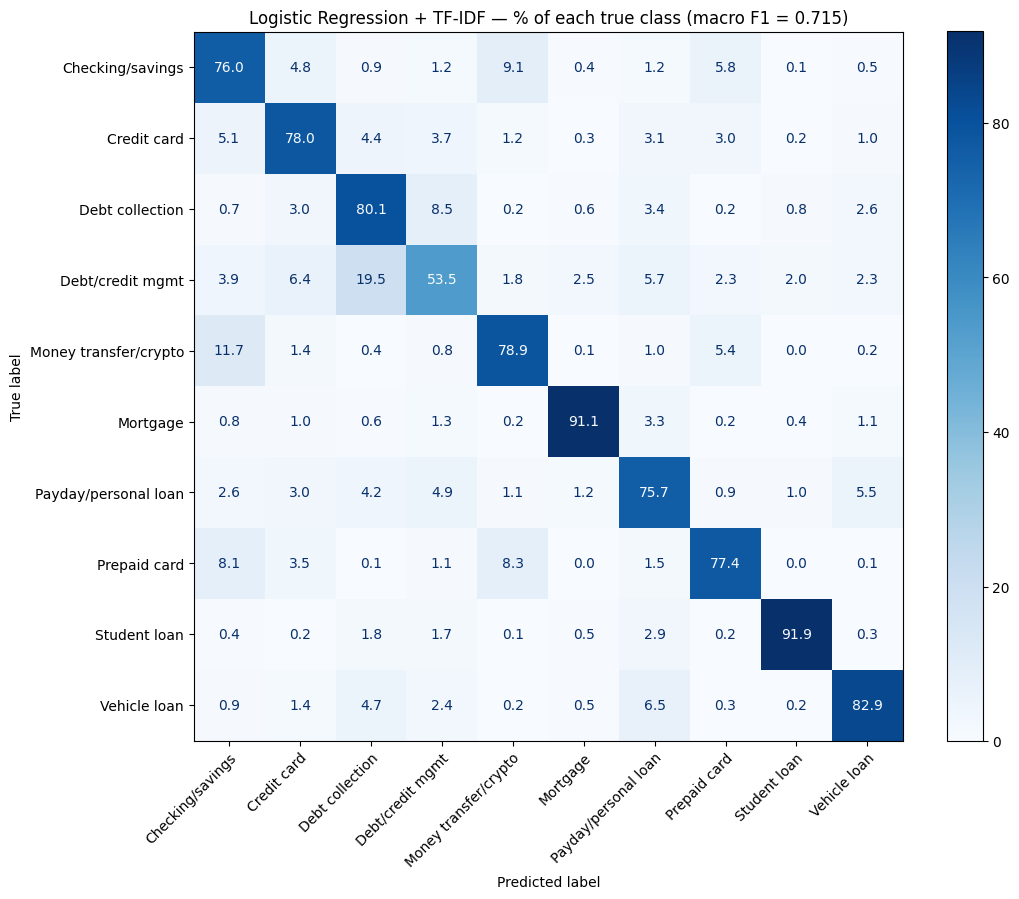

In [10]:
SHORT = {
    "Debt collection": "Debt collection",
    "Money transfer, virtual currency, or money service": "Money transfer/crypto",
    "Checking or savings account": "Checking/savings",
    "Credit card": "Credit card",
    "Mortgage": "Mortgage",
    "Vehicle loan or lease": "Vehicle loan",
    "Student loan": "Student loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/personal loan",
    "Prepaid card": "Prepaid card",
    "Debt or credit management": "Debt/credit mgmt",
}
short_labels = [SHORT.get(c, c) for c in labels]

cm = confusion_matrix(y_test, y_pred, labels=labels)

# Row-normalised: class supports now span 512 to ~14,800, so a raw-count matrix renders the
# rare-class rows invisible. Each row is the share of that true class sent to each label.
cm_pct = 100 * cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm_pct, display_labels=short_labels).plot(
    ax=ax, cmap="Blues", values_format=".1f", colorbar=True, xticks_rotation=45
)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
ax.set_title(f"Logistic Regression + TF-IDF — % of each true class (macro F1 = {macro_f1:.3f})")
fig.tight_layout()
fig.savefig("confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
print("saved confusion_matrix_lr.png  (row-normalised)")
plt.show()

### Interpretation — strongest/weakest classes and the top confusions

Computed rather than eyeballed, so the numbers quoted in the report's Business Insights
section come straight from the matrix.

In [11]:
per_class = pd.DataFrame({
    "f1": f1_score(y_test, y_pred, labels=labels, average=None, zero_division=0),
    "support": [int((y_test == c).sum()) for c in labels],
}, index=labels).sort_values("f1", ascending=False)
per_class["short"] = [SHORT[c] for c in per_class.index]

print("per-class F1 with support (support matters: it spans 512 to ~14,800):")
print(per_class[["short", "f1", "support"]].round(3).to_string(index=False))
print()
print(f"BEST : {per_class.index[0]!r}  F1={per_class.iloc[0]['f1']:.3f}  n={per_class.iloc[0]['support']:,}")
print(f"WORST: {per_class.index[-1]!r}  F1={per_class.iloc[-1]['f1']:.3f}  n={per_class.iloc[-1]['support']:,}")

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
pairs = [
    {"true": SHORT[t], "predicted": SHORT[p], "n": int(cm_df.loc[t, p]),
     "pct_of_true_class": 100 * cm_df.loc[t, p] / cm_df.loc[t].sum()}
    for t in labels for p in labels if t != p
]
top_conf = (pd.DataFrame(pairs).sort_values("pct_of_true_class", ascending=False)
            .head(10).reset_index(drop=True))
top_conf["pct_of_true_class"] = top_conf["pct_of_true_class"].round(1)
print("\ntop 10 confusions (share of the true class sent to the wrong label):")
print(top_conf.to_string(index=False))

per-class F1 with support (support matters: it spans 512 to ~14,800):
                short    f1  support
             Mortgage 0.920     3071
         Student loan 0.915     2088
      Debt collection 0.862    14777
          Credit card 0.812     8423
Money transfer/crypto 0.806     6714
     Checking/savings 0.793     9696
         Vehicle loan 0.790     2486
 Payday/personal loan 0.597     1681
         Prepaid card 0.450      751
     Debt/credit mgmt 0.200      512

BEST : 'Mortgage'  F1=0.920  n=3,071
WORST: 'Debt or credit management'  F1=0.200  n=512

top 10 confusions (share of the true class sent to the wrong label):
                 true             predicted    n  pct_of_true_class
     Debt/credit mgmt       Debt collection  100               19.5
Money transfer/crypto      Checking/savings  786               11.7
     Checking/savings Money transfer/crypto  887                9.1
      Debt collection      Debt/credit mgmt 1250                8.5
         Prepaid card M

### Why those pairs — lexical overlap between classes

The confusion matrix says *which* categories get mixed up; it does not say why. Represent
each class as the mean TF-IDF vector of its training complaints and the cosine between two
of those centroids is a measure of how much vocabulary the pair shares. Plotted against how
often the pair is actually swapped, it turns "these categories sound alike" into a testable
claim.

Similarity is measured on the **training** set (the vectoriser never saw test), the error
rate on the **held-out test** set, so the two axes come from disjoint data.


Spearman rho = 0.806   p = 2.28e-11   (n = 45 pairs)

most-confused pairs:
                                    pair  similarity  swapped  swapped_pct
Checking/savings / Money transfer/crypto       0.533     1673       10.195
      Debt collection / Debt/credit mgmt       0.766     1350        8.830
     Payday/personal loan / Vehicle loan       0.743      254        6.096
         Checking/savings / Prepaid card       0.638      624        5.973
    Money transfer/crypto / Prepaid card       0.449      425        5.693

most lexically similar pairs:
                                   pair  similarity  swapped  swapped_pct
     Debt collection / Debt/credit mgmt       0.766     1350        8.830
    Payday/personal loan / Vehicle loan       0.743      254        6.096
Debt/credit mgmt / Payday/personal loan       0.726      111        5.062
         Credit card / Debt/credit mgmt       0.720      347        3.884
         Checking/savings / Credit card       0.714      894        4.934


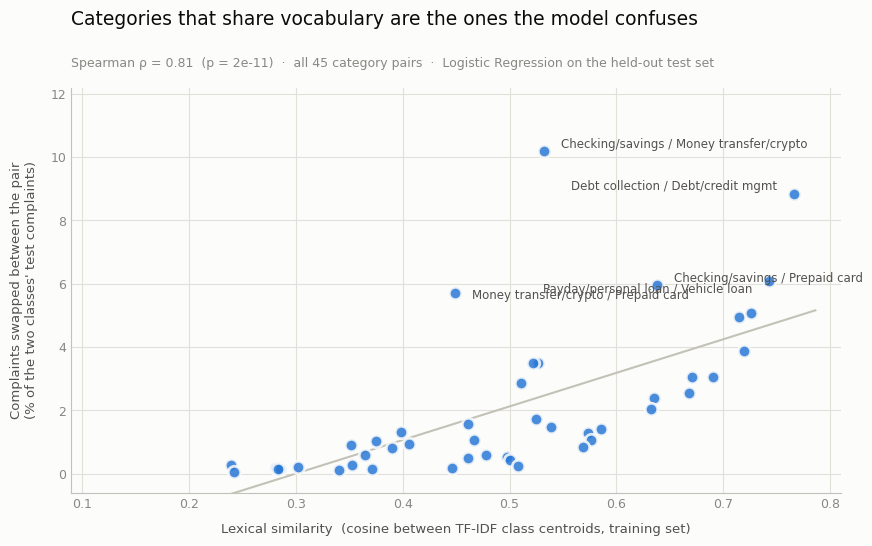

In [12]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

# Each class as the mean TF-IDF vector of its training complaints.
centroids = np.vstack(
    [np.asarray(X_train_tfidf[(y_train == c).values].mean(axis=0)).ravel() for c in labels]
)
similarity = cosine_similarity(centroids)

# Pair up every class pair: shared vocabulary vs how often they are swapped.
row_totals = cm.sum(axis=1)
pairs_df = pd.DataFrame([
    {
        "pair": f"{SHORT[labels[i]]} / {SHORT[labels[j]]}",
        "similarity": similarity[i, j],
        "swapped": int(cm[i, j] + cm[j, i]),
        # normalised so the big classes do not dominate purely by being big
        "swapped_pct": 100 * (cm[i, j] + cm[j, i]) / (row_totals[i] + row_totals[j]),
    }
    for i in range(len(labels)) for j in range(i + 1, len(labels))
])

rho, p_value = spearmanr(pairs_df["similarity"], pairs_df["swapped_pct"])
print(f"Spearman rho = {rho:.3f}   p = {p_value:.2e}   (n = {len(pairs_df)} pairs)")
print()
print("most-confused pairs:")
print(pairs_df.nlargest(5, "swapped_pct").round(3).to_string(index=False))
print()
print("most lexically similar pairs:")
print(pairs_df.nlargest(5, "similarity").round(3).to_string(index=False))

# --- chart ---------------------------------------------------------------
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES = "#e1e0d9", "#c3c2b7", "#2a78d6"

fig, ax = plt.subplots(figsize=(9, 5.6))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

# Straight-line guide, drawn under the marks; the quoted statistic is the rank
# correlation, so the line is a reading aid rather than the model being claimed.
slope, intercept = np.polyfit(pairs_df["similarity"], pairs_df["swapped_pct"], 1)
xs = np.linspace(pairs_df["similarity"].min() - 0.02, pairs_df["similarity"].max() + 0.02, 50)
ax.plot(xs, intercept + slope * xs, color=AXIS, lw=1.5, zorder=1)

ax.scatter(pairs_df["similarity"], pairs_df["swapped_pct"], s=80, c=SERIES,
           alpha=0.85, edgecolors=SURFACE, linewidths=2, zorder=3)

# Label the extremes and the off-trend pairs only — a label on all 45 is unreadable.
ANNOTATE = {
    "Debt collection / Debt/credit mgmt": (-12, 3, "right"),
    "Payday/personal loan / Vehicle loan": (-12, -9, "right"),
    "Checking/savings / Money transfer/crypto": (12, 2, "left"),
    "Money transfer/crypto / Prepaid card": (12, -4, "left"),
    "Checking/savings / Prepaid card": (12, 2, "left"),
}
for _, r in pairs_df.iterrows():
    if r["pair"] in ANNOTATE:
        dx, dy, ha = ANNOTATE[r["pair"]]
        ax.annotate(r["pair"], (r["similarity"], r["swapped_pct"]),
                    textcoords="offset points", xytext=(dx, dy), ha=ha,
                    fontsize=8.5, color=INK2, zorder=4)

ax.set_axisbelow(True)
ax.grid(True, color=GRID, lw=0.8, zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
    ax.spines[side].set_linewidth(0.8)
ax.tick_params(colors=MUTED, labelsize=9, length=0)
ax.set_xlabel("Lexical similarity  (cosine between TF-IDF class centroids, training set)",
              fontsize=9.5, color=INK2, labelpad=9)
ax.set_ylabel("Complaints swapped between the pair\n(% of the two classes' test complaints)",
              fontsize=9.5, color=INK2, labelpad=9)
ax.set_xlim(0.09, 0.81)
ax.set_ylim(-0.6, 12.2)
ax.text(0, 1.145, "Categories that share vocabulary are the ones the model confuses",
        transform=ax.transAxes, fontsize=13.5, color=INK, va="bottom")
ax.text(0, 1.045,
        f"Spearman \u03c1 = {rho:.2f}  (p = {p_value:.0e})  \u00b7  all {len(pairs_df)} "
        "category pairs  \u00b7  Logistic Regression on the held-out test set",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")

fig.tight_layout()
fig.savefig("lexical_similarity_vs_confusion.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
print("\nsaved lexical_similarity_vs_confusion.png")
plt.show()


#### The two off-trend pairs — a centroid is an average

Money transfer sits far from Checking/savings on the class-level measure yet still loses
complaints to it. That looks like a counter-example until you remember a centroid averages
the whole class: if a class holds two kinds of complaint, the average describes neither.
Comparing the misrouted documents against the correctly-classified ones settles it.


In [13]:
MT = "Money transfer, virtual currency, or money service"
CK = "Checking or savings account"
i_mt, i_ck = labels.index(MT), labels.index(CK)

is_mt = (y_test == MT).values
misrouted = is_mt & (y_pred == CK)          # true Money transfer, called Checking
correct = is_mt & (y_pred == MT)

# How close is each individual document to each of the two class centroids?
to_mt = cosine_similarity(X_test_tfidf, centroids[i_mt].reshape(1, -1)).ravel()
to_ck = cosine_similarity(X_test_tfidf, centroids[i_ck].reshape(1, -1)).ravel()

print(f"Money transfer in the test set : {is_mt.sum()}")
print(f"  classified correctly         : {correct.sum()}")
print(f"  sent to Checking/savings     : {misrouted.sum()}")
print()
print(f"{'group':<30}{'-> MT centroid':>16}{'-> CK centroid':>16}")
for name, mask in [("correctly classified", correct), ("sent to Checking/savings", misrouted)]:
    print(f"{name:<30}{to_mt[mask].mean():>16.3f}{to_ck[mask].mean():>16.3f}")
print(f"\n(class centroids themselves sit {similarity[i_mt, i_ck]:.3f} apart)")

# Which terms pushed these documents across? Positive = toward Checking/savings.
feature_names = np.array(vectorizer.get_feature_names_out())
coef_gap = clf.coef_[i_ck] - clf.coef_[i_mt]
pushed_by = np.asarray(X_test_tfidf[misrouted].multiply(coef_gap).sum(axis=0)).ravel()
print("\nterms pushing them toward Checking/savings, and how common each one is:")
seen = X_train_tfidf > 0
print(f"  {'term':<18}{'in MT complaints':>18}{'in CK complaints':>18}")
for t in np.argsort(pushed_by)[::-1][:8]:
    print(f"  {feature_names[t]:<18}{seen[(y_train == MT).values, t].mean():>17.1%}"
          f"{seen[(y_train == CK).values, t].mean():>18.1%}")

print("\nwhat the misrouted complaints actually say:")
for text in X_test[misrouted].head(3):
    print("  -", " ".join(text.split())[:190], "...")


Money transfer in the test set : 6714
  classified correctly         : 5295
  sent to Checking/savings     : 786

group                           -> MT centroid  -> CK centroid
correctly classified                     0.306           0.131
sent to Checking/savings                 0.114           0.206

(class centroids themselves sit 0.533 apart)



terms pushing them toward Checking/savings, and how common each one is:
  term                in MT complaints  in CK complaints
  bank                          24.9%             53.2%
  account                       65.2%             80.1%


  checking                       4.2%             20.9%
  chase                          3.2%              9.7%
  deposit                        5.5%             20.3%
  check                          5.4%             20.3%
  branch                         2.2%             12.1%


  card                          10.2%             24.1%

what the misrouted complaints actually say:
  - Scam occurred on XX/XX/XXXX XXXX minor daughter was scammed via phone by someone posing as her banking institution ( NFCU ). Immediately discovering she was a victim we reached out to both i ...
  - I went through cash app and I tried to open an account and every time I verify myself they automatically blocked my account I don't know why this is going on I haven't done anything wrong I' ...
  - I had been working on a service app called XXXX XXXX, I had done walks and was paid for the service but when I realized where the funds were going I needed to gain access to my account, My o ...


#### How many groups is Money transfer, really?

The comparison above splits the class by whether the model got it right, which is circular:
grouping by the outcome you want to explain will always produce groups. The honest test is
to cluster the class on its text alone and only then ask where the errors landed.

k-means needs `k` supplied and returns `k` clusters whether or not they exist, so the
silhouette is printed for k=2..8 before any k is chosen. It does not settle the question:
the score never peaks and every value sits in the 0.11-0.17 band, which is weak structure.
The finding that survives is not the cluster count but the **error concentration** -- the
misroutes pile into a single cluster at every k tested.


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

mt_train = X_train_tfidf[(y_train == MT).values]
mt_test = X_test_tfidf[(y_test == MT).values]
mt_misrouted = misrouted[(y_test == MT).values]

print(f"choosing k on {mt_train.shape[0]} Money transfer training complaints")
print(f"{'k':>2}{'inertia':>10}{'silhouette':>12}   errors in the worst cluster")
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(mt_train)
    sil = silhouette_score(mt_train, km.labels_, sample_size=2000, random_state=RANDOM_STATE)
    assigned = km.predict(mt_test)
    worst = max(mt_misrouted[assigned == c].sum() for c in range(k))
    print(f"{k:>2}{km.inertia_:>10.1f}{sil:>12.3f}   {worst} of {mt_misrouted.sum()}")

# Read the table before trusting k: the silhouette never peaks -- it climbs slowly all the
# way to k=8, and every value is in the 0.11-0.17 range, which is weak cluster structure.
# So k=3 is NOT chosen by a clear elbow. What IS stable is the error concentration: every
# misroute sits in one cluster from k=2 through k=7. k=3 is reported because it is the
# smallest k at which the two template campaigns separate from the general-language group.
K = 3
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(mt_train)
assigned = km.predict(mt_test)

print(f"\nk={K}: what each group is, and where the errors sit")
for c in range(K):
    top = feature_names[np.argsort(km.cluster_centers_[c])[::-1][:8]]
    in_c = assigned == c
    print(f"\n  group {c}  ({(km.labels_ == c).sum()} train, {in_c.sum()} test)"
          f"  ->  {mt_misrouted[in_c].sum()} misrouted to Checking/savings")
    print(f"    {', '.join(top)}")


choosing k on 8000 Money transfer training complaints
 k   inertia  silhouette   errors in the worst cluster


 2    6510.7       0.112   786 of 786


 3    5916.5       0.157   786 of 786


 4    5780.2       0.160   773 of 786


 5    5691.9       0.165   770 of 786


 6    5640.1       0.164   769 of 786


 7    5601.5       0.166   769 of 786


 8    5571.6       0.167   553 of 786



k=3: what each group is, and where the errors sit

  group 0  (5618 train, 4672 test)  ->  786 misrouted to Checking/savings
    account, money, app, cash, cash app, paypal, funds, bank

  group 1  (1385 train, 1145 test)  ->  0 misrouted to Checking/savings
    cash app, unfair, cash, app, resolution, act, unprotected, fraud platform

  group 2  (997 train, 897 test)  ->  0 misrouted to Checking/savings
    zelle, concerns, issues platform, handling disputes, cfpb lawsuit, zelle failed, offenders, significant issues


## Step 7 — What the prior shift costs, and what the cap costs

Two questions the first version of this notebook could not ask, because its test set was
near-uniform and its cap was tangled up with its imbalance handling.

**The prior shift.** `class_weight='balanced'` fits the model to a uniform class prior; the
test set runs at about 29:1. Standard label-shift correction adds the log of the evaluation
prior to the logits. Because the effective training prior is uniform, the `- log π_train`
term is a constant and drops out of the softmax:

    z'_k = z_k + log π_eval(k)

Applying it makes `argmax` the Bayes rule for accuracy. It should therefore **raise accuracy
and lower macro F1** — the two objectives genuinely disagree, and reporting only the flattering
one of the pair would be the same mistake this notebook is trying to correct. Both operating
points are reported; **the choice between them is made on validation**, never on test.

In [15]:
# Guard: the correction below assumes softmax(decision_function) == predict_proba, which
# holds for the multinomial parameterisation but not for one-vs-rest.
assert np.allclose(softmax(clf.decision_function(X_val_tfidf[:200]), axis=1),
                   clf.predict_proba(X_val_tfidf[:200])), "not a softmax parameterisation"

log_prior = np.log(pool["product"].value_counts(normalize=True).reindex(clf.classes_).values)

def prior_corrected(Xt):
    return clf.classes_[np.argmax(clf.decision_function(Xt) + log_prior, axis=1)]

print(f"{'':<22}{'macro F1':>10}{'accuracy':>10}{'bal. acc':>10}   (validation set)")
for name, pred in [("uniform-prior", clf.predict(X_val_tfidf)),
                   ("prior-corrected", prior_corrected(X_val_tfidf))]:
    print(f"{name:<22}{f1_score(y_val, pred, average='macro', zero_division=0):>10.4f}"
          f"{accuracy_score(y_val, pred):>10.4f}"
          f"{balanced_accuracy_score(y_val, pred):>10.4f}")

print("\nSelected on validation, then applied once to test:")
y_pred_corr = prior_corrected(X_test_tfidf)
print(f"{'uniform-prior   (test)':<24}"
      f"macro F1 {macro_f1:.4f}   accuracy {accuracy:.4f}")
print(f"{'prior-corrected (test)':<24}"
      f"macro F1 {f1_score(y_test, y_pred_corr, average='macro', zero_division=0):.4f}"
      f"   accuracy {accuracy_score(y_test, y_pred_corr):.4f}")

                        macro F1  accuracy  bal. acc   (validation set)


uniform-prior             0.7131    0.7962    0.7829


prior-corrected           0.7393    0.8314    0.7033

Selected on validation, then applied once to test:
uniform-prior   (test)  macro F1 0.7147   accuracy 0.7963


prior-corrected (test)  macro F1 0.7414   accuracy 0.8297


In [16]:
# What does the 8,000-per-class cap actually cost? Train the same model on the full
# training pool (~234k rows) and score it on the same test set. LR makes this cheap;
# for DistilBERT it would be roughly 80 minutes of GPU, which is why the cap exists.
full_train = train_pool.reset_index(drop=True)
vec_full = TfidfVectorizer(max_features=20_000, stop_words="english", ngram_range=(1, 2))
Xf = vec_full.fit_transform(full_train["narrative"].map(clean_text))

t0 = time.time()
clf_full = LogisticRegression(class_weight="balanced", max_iter=1000,
                              random_state=RANDOM_STATE).fit(Xf, full_train["product"])
t_full = time.time() - t0
pred_full = clf_full.predict(vec_full.transform(X_test_clean))

print(f"{'training set':<34}{'rows':>10}{'fit (s)':>10}{'macro F1':>10}{'accuracy':>10}")
print(f"{'capped at 8,000/class':<34}{len(train_df):>10,}{t_fit:>10.1f}{macro_f1:>10.4f}{accuracy:>10.4f}")
print(f"{'full training pool':<34}{len(full_train):>10,}{t_full:>10.1f}"
      f"{f1_score(y_test, pred_full, average='macro', zero_division=0):>10.4f}"
      f"{accuracy_score(y_test, pred_full):>10.4f}")
print("\nThe gap is the price of the compute budget -- charge it to the cap, not to the method.")

training set                            rows   fit (s)  macro F1  accuracy
capped at 8,000/class                 69,737      10.0    0.7147    0.7963
full training pool                   234,260      38.0    0.7284    0.8135

The gap is the price of the compute budget -- charge it to the cap, not to the method.


## Step 8 — The temporal split: what happens on months the model has never seen

The random split grades the model on the average of 2025-01 to 2026-07. No month looks like
that average — Money transfer alone runs from 42% of 2025Q1 to 4.5% of 2026Q3. The temporal
split is the honest version of the question: train on the past, test on the future.

Caveats that belong next to these numbers: the temporal test set holds ~176 rows of the
rarest class, so its per-class F1 is noisy; and 2026-06/07 are still filling in (6.1k and
1.8k complaints against a ~18k monthly norm), so the tail is thin as well as small.

In [17]:
t_train = pd.read_parquet("train_temporal.parquet")
t_val = pd.read_parquet("val_temporal.parquet")
t_test = pd.read_parquet("test_temporal.parquet")

vec_t = TfidfVectorizer(max_features=20_000, stop_words="english", ngram_range=(1, 2))
Xt_train = vec_t.fit_transform(t_train["narrative"].map(clean_text))
Xt_test = vec_t.transform(t_test["narrative"].map(clean_text))

clf_t = LogisticRegression(class_weight="balanced", max_iter=1000,
                           random_state=RANDOM_STATE).fit(Xt_train, t_train["product"])
pred_t = clf_t.predict(Xt_test)

mf_t = f1_score(t_test["product"], pred_t, average="macro", zero_division=0)
ac_t = accuracy_score(t_test["product"], pred_t)

print(f"{'split':<34}{'test rows':>11}{'macro F1':>10}{'accuracy':>10}")
print(f"{'random (pooled 19 months)':<34}{len(y_test):>11,}{macro_f1:>10.4f}{accuracy:>10.4f}")
print(f"{'temporal (unseen months)':<34}{len(t_test):>11,}{mf_t:>10.4f}{ac_t:>10.4f}")
print(f"\nGAP: {mf_t - macro_f1:+.4f} macro F1")
print()
print("per-class, temporal split (support included -- the rare classes are thin here):")
t_labels = sorted(t_test["product"].unique())
print(pd.DataFrame({
    "class": [SHORT[c] for c in t_labels],
    "f1": f1_score(t_test["product"], pred_t, labels=t_labels, average=None, zero_division=0),
    "support": [int((t_test["product"] == c).sum()) for c in t_labels],
}).round(3).to_string(index=False))

split                               test rows  macro F1  accuracy
random (pooled 19 months)              50,199    0.7147    0.7963
temporal (unseen months)               22,020    0.6998    0.7913

GAP: -0.0149 macro F1

per-class, temporal split (support included -- the rare classes are thin here):
                class    f1  support
     Checking/savings 0.789     4904
          Credit card 0.829     4608
      Debt collection 0.864     5735
     Debt/credit mgmt 0.175      176
Money transfer/crypto 0.655     1814
             Mortgage 0.930     1727
 Payday/personal loan 0.626      823
         Prepaid card 0.391      294
         Student loan 0.897      672
         Vehicle loan 0.841     1267


## Step 9 — Is the LR/DistilBERT gap real?

Both models score the same test rows, so the comparison is **paired** and the right tools are
a paired bootstrap on the macro-F1 difference and McNemar's test on the per-row hits. The
marginal confidence interval on a rare class is roughly +/-0.035 at this support, which is
wide enough to swallow most of the per-class differences the first version of the README
reported as findings.

Run this cell after `distilbert_test_predictions.csv` exists (the DistilBERT notebook writes
it). Until then it reports the LR interval alone.

In [18]:
def paired_bootstrap(y_true, pred_a, pred_b, n=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true, pred_a, pred_b = map(np.asarray, (y_true, pred_a, pred_b))
    idx = np.arange(len(y_true))
    diffs = np.empty(n)
    for i in range(n):
        s = rng.choice(idx, size=len(idx), replace=True)
        diffs[i] = (f1_score(y_true[s], pred_b[s], average="macro", zero_division=0)
                    - f1_score(y_true[s], pred_a[s], average="macro", zero_division=0))
    return diffs

if os.path.exists("distilbert_test_predictions.csv"):
    db = pd.read_csv("distilbert_test_predictions.csv")
    assert len(db) == len(y_test), "DistilBERT predictions do not match this test set"
    pred_db = db["prediction"].values

    d = paired_bootstrap(y_test.values, y_pred, pred_db)
    lo, hi = np.percentile(d, [2.5, 97.5])
    print(f"delta macro F1 (DistilBERT - LR): {d.mean():+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]")
    print("  -> CI crosses zero; the difference is not resolved at this sample size."
          if lo < 0 < hi else "  -> CI excludes zero; the difference is real.")

    # McNemar with continuity correction. Only the discordant pairs carry information:
    # rows both models get right, or both get wrong, say nothing about which is better.
    a = (y_pred == y_test.values); b = (pred_db == y_test.values)
    n01 = int((a & ~b).sum())   # LR right, DistilBERT wrong
    n10 = int((~a & b).sum())   # DistilBERT right, LR wrong
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    print(f"\nMcNemar: LR-only-correct {n01:,} vs DistilBERT-only-correct {n10:,}")
    print(f"  chi2 = {stat:.2f}   p = {chi2.sf(stat, 1):.3e}")
else:
    print("distilbert_test_predictions.csv not found -- run the DistilBERT notebook first.")
    print()
    d = paired_bootstrap(y_test.values, y_pred, y_pred, n=200)
    per_class_ci = {}
    rng = np.random.default_rng(RANDOM_STATE)
    for c in ["Debt or credit management", "Debt collection"]:
        m = (y_test == c).values
        n_c = int(m.sum())
        f1c = f1_score(y_test, y_pred, labels=[c], average="macro", zero_division=0)
        print(f"{SHORT[c]:<24} n={n_c:>6,}  F1={f1c:.3f}  "
              f"approx 95% CI half-width +/-{1.96 * np.sqrt(f1c * (1 - f1c) / n_c):.3f}")

distilbert_test_predictions.csv not found -- run the DistilBERT notebook first.



Debt/credit mgmt         n=   512  F1=0.200  approx 95% CI half-width +/-0.035
Debt collection          n=14,777  F1=0.862  approx 95% CI half-width +/-0.006
